# 04 – Augmentation and Hyperparameter Tuning

In this notebook, we extend the pretrained encoder from the previous notebook by experimenting with:

- Learning rate
- MAE vs SSIM loss weighting (`mae_weight`)
- Bottleneck size
- Encoder freezing
- Data augmentation strength

The goal is to evaluate how these factors affect reconstruction performance and anomaly detection capability on the MVTec AD cable dataset.

## 1. Imports & Setup

In [2]:
import sys
sys.path.insert(0, '../src')

import copy
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from utils import GROUND_TRUTH_DIR

from utils import set_seed, CHECKPOINTS_DIR
from dataset import get_dataloaders, get_eval_transform
from models_pretrained import ResNetAutoencoder
from masking import (
    generate_cable_mask,
    masked_mae_loss,
    masked_ssim_loss,
    compute_masked_error_map,
)

from torchmetrics.functional import structural_similarity_index_measure
from sklearn.metrics import roc_auc_score as _roc_auc
from sklearn.metrics import precision_recall_curve as _prc
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score,
    confusion_matrix
)

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_MASKING = False

# ImageNet stats for pretrained ResNet encoder inputs.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

def normalize_for_encoder(x):
    mean = IMAGENET_MEAN.to(x.device)
    std = IMAGENET_STD.to(x.device)
    return (x - mean) / std

print(f'Using device: {DEVICE}')
print(f'Background masking: {USE_MASKING}')

d:\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Background masking: False


# 2. Weight Initialization

In [3]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)     

# 3. Dataloaders

In [4]:
#BATCH_SIZE = 16
BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, val_split=0.15, seed=42
)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)

print(f'Train samples : {n_train}')
print(f'Val   samples : {n_val}')
print(f'Test  samples : {n_test}')
print(f'Train + Val   : {n_train + n_val}  (expected 224)')

Train samples : 191
Val   samples : 33
Test  samples : 150
Train + Val   : 224  (expected 224)


In [5]:
# Inspect a batch shape
sample_batch = next(iter(train_loader))
print(f'Batch shape : {sample_batch.shape}')  # [16, 3, 256, 256]
print(f'Dtype       : {sample_batch.dtype}')
print(f'Min / Max   : {sample_batch.min():.3f} / {sample_batch.max():.3f}')

Batch shape : torch.Size([32, 3, 256, 256])
Dtype       : torch.float32
Min / Max   : 0.000 / 1.000


# 4. Loss Function

In [6]:
def compute_loss(output, target, mask=None, mae_weight=0.4):
    if USE_MASKING and mask is not None:
        mae  = masked_mae_loss(output, target, mask)
        ssim = masked_ssim_loss(output, target, mask)
    else:
        mae  = torch.nn.functional.l1_loss(output, target)
        ssim = 1.0 - structural_similarity_index_measure(output, target, data_range=1.0)

    loss = mae_weight * mae + (1 - mae_weight) * ssim
    return loss, mae, ssim

# 5. Training Model

In [7]:
def train_model_full(model, checkpoint_name, LR, MAE_WEIGHT=0.4, NUM_EPOCHS=50, PATIENCE=15):
    """Train model with masked MAE+SSIM loss and early stopping."""
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses, val_losses = [], []
    best_val_loss  = float('inf')
    best_epoch     = 0
    wait           = 0
    best_state     = copy.deepcopy(model.state_dict())

    for epoch in range(1, NUM_EPOCHS + 1):
        # --- Train ---
        model.train()
        running = 0.0
        running_mae = 0.0
        running_ssim = 0.0
        
        for imgs in train_loader:
            imgs = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            optimizer.zero_grad()
            recon = model(imgs_enc)

            mask = generate_cable_mask(imgs) if USE_MASKING else None

            loss, loss_mae, loss_ssim = compute_loss(
                recon, imgs, mask, MAE_WEIGHT
            )
            loss.backward()
            optimizer.step()

            running += loss.item() * imgs.size(0)
            running_mae += loss_mae.item() * imgs.size(0)
            running_ssim += loss_ssim.item() * imgs.size(0)

        train_loss = running / len(train_loader.dataset)
        train_mae  = running_mae / len(train_loader.dataset)
        train_ssim_d = running_ssim / len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        running_val = 0.0
        running_val_mae = 0.0
        running_val_ssim = 0.0
        
        with torch.no_grad():
            for imgs in val_loader:
                imgs  = imgs.to(DEVICE)
                imgs_enc = normalize_for_encoder(imgs)
                recon = model(imgs_enc)
                mask = generate_cable_mask(imgs) if USE_MASKING else None
                
                v_loss, val_mae, val_ssim = compute_loss(
                    recon, imgs, mask, MAE_WEIGHT
                )

                running_val += v_loss.item() * imgs.size(0)
                running_val_mae += val_mae.item() * imgs.size(0)
                running_val_ssim += val_ssim.item() * imgs.size(0)

        val_loss = running_val / len(val_loader.dataset)
        val_mae  = running_val_mae / len(val_loader.dataset)
        val_ssim_d = running_val_ssim / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch    = epoch
            wait          = 0
            best_state    = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{checkpoint_name}] Epoch {epoch:3d}/{NUM_EPOCHS}  '
                  f'train_loss={train_loss:.6f}  val_loss={val_loss:.6f}')
            print(f'    components: train_mae={train_mae:.6f}, train_(1-ssim)={train_ssim_d:.6f}  '
                  f'val_mae={val_mae:.6f}, val_(1-ssim)={val_ssim_d:.6f}')

        if wait >= PATIENCE:
            print(f'Early stopping at epoch {epoch} '
                  f'(best epoch={best_epoch}, best_val={best_val_loss:.6f})')
            break

    model.load_state_dict(best_state)
    CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), CHECKPOINTS_DIR / checkpoint_name)
    print(f'Saved checkpoint -> {CHECKPOINTS_DIR / checkpoint_name}')
    return model, {'train': train_losses, 'val': val_losses}

## 6. Image-level Evaluation

### 6.1 Compute Anomaly Scores on Test Set

In [8]:
def compute_scores(model, loader_test, loader_val, MAE_WEIGHT=0.4):
    """Return (mae_scores, combined_scores, all_labels, val_combined_errors) arrays."""
    mae_scores, ssim_dissim_scores, all_labels = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader_test:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)

            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                batch_mae = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                batch_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            mae_scores.extend(batch_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i    = generate_cable_mask(imgs[i:i+1])
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                ssim_dissim_scores.append(1.0 - ssim_i)

            all_labels.extend(labels.tolist())

    mae_scores          = np.array(mae_scores)
    ssim_dissim_scores  = np.array(ssim_dissim_scores)
    combined_scores     = MAE_WEIGHT * mae_scores + (1.0 - MAE_WEIGHT) * ssim_dissim_scores
    all_labels          = np.array(all_labels)

    # Val-set combined errors for threshold calibration
    val_mae_list, val_ssim_list = [], []
    with torch.no_grad():
        for imgs in loader_val:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)
            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                b_mae   = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                b_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            val_mae_list.extend(b_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i = generate_cable_mask(imgs[i:i+1])
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                val_ssim_list.append(1.0 - s_i)

    val_mae  = np.array(val_mae_list)
    val_ssim = np.array(val_ssim_list)
    val_combined = MAE_WEIGHT * val_mae + (1.0 - MAE_WEIGHT) * val_ssim

    return mae_scores, combined_scores, all_labels, val_combined


### 6.2 Full Test Set Evaluation (ROC-AUC, F1, etc.)

In [9]:
def full_test_eval(labels, combined_scores, val_combined,
                   tag='Model', QUANTILES=None,
                   SELECTION_POLICY='max-f1', MAX_FPR=0.1,
                   plot_ax=None):

#Evaluate test-level metrics and optionally plot ROC.
    if QUANTILES is None:
        QUANTILES = [0.2, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99]

    auc = roc_auc_score(labels, combined_scores)
    ap  = average_precision_score(labels, combined_scores)

    sweep_rows = []
    for q in QUANTILES:
        threshold = float(np.quantile(val_combined, q))
        preds = (combined_scores >= threshold).astype(int)

        prec = precision_score(labels, preds, zero_division=0)
        rec  = recall_score(labels, preds, zero_division=0)
        f1   = f1_score(labels, preds, zero_division=0)
        acc  = accuracy_score(labels, preds)
        bacc = balanced_accuracy_score(labels, preds)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
        fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

        sweep_rows.append({
            'q': q, 'threshold': threshold,
            'f1': f1, 'rec': rec, 'prec': prec,
            'acc': acc, 'bacc': bacc,
            'fpr': fpr_at_thr, 'fnr': fnr,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        })

    if SELECTION_POLICY == 'fpr-constrained':
        feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
        if feasible:
            selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
        else:
            selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
    else:
        selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

    threshold = selected['threshold']
    results_dict = dict(
        auc=auc, ap=ap, f1=selected['f1'], rec=selected['rec'], prec=selected['prec'],
        acc=selected['acc'], bacc=selected['bacc'], fpr=selected['fpr'], fnr=selected['fnr'],
        tn=selected['tn'], fp=selected['fp'], fn=selected['fn'], tp=selected['tp'],
        threshold=threshold, quantile=selected['q'], policy=SELECTION_POLICY,
    )

    if plot_ax is not None:
        fpr_c, tpr_c, roc_thr = roc_curve(labels, combined_scores)
        plot_idx = np.argmin(np.abs(roc_thr - threshold))
        plot_ax.plot(fpr_c, tpr_c, label=f'ROC (AUC={auc:.3f})')
        plot_ax.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
                        label=f'Selected thr ({threshold:.3f})')
        plot_ax.plot([0,1],[0,1],'k--', linewidth=0.8)
        plot_ax.set_xlabel('FPR')
        plot_ax.set_ylabel('TPR')
        plot_ax.set_title(f'ROC — {tag}')
        plot_ax.legend()

    # Print summary
    print(f'\n[{tag}] policy={SELECTION_POLICY}')
    print(f'  Selected quantile={selected["q"]:.2f}, threshold={threshold:.6f}')
    print(f'  ROC-AUC  : {auc:.4f}   PR-AUC: {ap:.4f}')
    print(f'  F1       : {selected["f1"]:.4f}   Recall: {selected["rec"]:.4f}   Precision: {selected["prec"]:.4f}')
    print(f'  Accuracy : {selected["acc"]:.4f}   Balanced: {selected["bacc"]:.4f}')
    print(f'  FPR      : {selected["fpr"]:.4f}   FNR: {selected["fnr"]:.4f}')
    print(f'  Confusion: TN={selected["tn"]}  FP={selected["fp"]}  FN={selected["fn"]}  TP={selected["tp"]}')
    print('  Sweep (q, F1, Recall, Precision, FPR):')
    for r in sweep_rows:
        print(f'    q={r["q"]:.2f}  f1={r["f1"]:.4f}  rec={r["rec"]:.4f}  prec={r["prec"]:.4f}  fpr={r["fpr"]:.4f}')

    return results_dict, sweep_rows

## 7. Pixel-level Evaluation

Per-pixel error maps are computed for both models; we report pixel AUROC and mean IoU (sweep over threshold candidates). Overlay visualisation uses the best-performing model.

In [10]:
eval_tf = get_eval_transform()

def pixel_eval(model, tag):
    dataset = test_loader.dataset
    pixel_scores_all, pixel_gt_all = [], []
    err_maps, gt_masks_256 = [], []

    model.eval()
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_path, label = dataset.samples[idx]
            if label == 0:
                continue

            category  = img_path.parent.name
            stem      = img_path.stem
            mask_path = GROUND_TRUTH_DIR / category / f'{stem}_mask.png'

            img_t = eval_tf(PILImage.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
            img_t_enc = normalize_for_encoder(img_t)
            recon = model(img_t_enc)

            if USE_MASKING:
                cable_mask = generate_cable_mask(img_t)
                err_map    = compute_masked_error_map(recon, img_t, cable_mask)
            else:
                err_map = torch.mean(torch.abs(recon - img_t), dim=1).squeeze(0).cpu().numpy()

            gt_raw = np.array(
                PILImage.open(mask_path).convert('L').resize((256, 256), PILImage.NEAREST)
            )
            gt_bin = (gt_raw > 127).astype(np.uint8)

            err_maps.append(err_map)
            gt_masks_256.append(gt_bin)
            pixel_scores_all.extend(err_map.ravel())
            pixel_gt_all.extend(gt_bin.ravel())

    pixel_scores_all = np.array(pixel_scores_all)
    pixel_gt_all     = np.array(pixel_gt_all)

    px_auc = _roc_auc(pixel_gt_all, pixel_scores_all)

    _, _, px_thr = _prc(pixel_gt_all, pixel_scores_all)
    candidates = px_thr[::max(1, len(px_thr) // 200)]
    best_thr, best_miou = 0.0, -1.0
    for thr in candidates:
        ious = []
        for em, gt in zip(err_maps, gt_masks_256):
            pred  = (em >= thr).astype(np.uint8)
            inter = int((pred & gt).sum())
            union = int((pred | gt).sum())
            ious.append(inter / (union + 1e-8))
        m = float(np.mean(ious))
        if m > best_miou:
            best_miou, best_thr = m, float(thr)

    per_image_ious = []
    for em, gt in zip(err_maps, gt_masks_256):
        pred  = (em >= best_thr).astype(np.uint8)
        inter = int((pred & gt).sum())
        union = int((pred | gt).sum())
        per_image_ious.append(inter / (union + 1e-8))
    per_image_ious = np.array(per_image_ious)

    print(f'[{tag}]  Pixel AUROC: {px_auc:.4f}  '
          f'Optimal threshold: {best_thr:.6f}  '
          f'Mean IoU: {per_image_ious.mean():.4f}  '
          f'Std IoU: {per_image_ious.std():.4f}')

    return err_maps, gt_masks_256, per_image_ious, best_thr, px_auc

# 8. Summary Comparison

In [11]:
def print_summary(test_results, pixel_results=None):
    """
    test_results  : dict of {tag: results_dict} from full_test_eval
    pixel_results : dict of {tag: (pixel_auroc, mean_iou)} from pixel_eval
    """
    # Header
    col_width = 36 
    header_tags = list(test_results.keys())
    header = f"{'Metric':<22}" + ''.join([f"{tag:>{col_width}}" for tag in header_tags])
    print(header)
    print('-' * (22 + col_width *  len(header_tags)))

    metrics = [
        ('ROC-AUC', 'auc'),
        ('PR-AUC', 'ap'),
        ('F1', 'f1'),
        ('Recall', 'recall'),
        ('Precision', 'precision'),
        ('Accuracy', 'accuracy'),
        ('Balanced Acc','bacc'),
        ('Threshold', 'reference_threshold'),
        ('FPR', 'fpr'),
        ('FNR', 'fnr'),
    ]

    for label, key in metrics:
        row = f"{label:<22}"
        for tag in header_tags:
            val = test_results[tag].get(key, None)
            if val is None:
                row += f"{'N/A':>{col_width}}"
            else:
                row += f"{val:>{col_width}.4f}"
        print(row)

    # Pixel-level metrics if provided
    if pixel_results is not None:
        print('-' * (22 + col_width * len(header_tags)))
        for metric_name in ['Pixel AUROC', 'Mean IoU']:
            row = f"{metric_name:<22}"
            for tag in header_tags:
                if tag not in pixel_results:
                    row += f"{'N/A':>{col_width}}"
                else:
                    if metric_name == 'Pixel AUROC':
                        val = pixel_results[tag][0]
                    else:
                        val = pixel_results[tag][1]
                    row += f"{val:>{col_width}.4f}"
            print(row)

# 9. Tuning Experiments

In [12]:
def run_experiment(cfg):
    print(f"\nRunning: {cfg['name']}")

    model = ResNetAutoencoder(
        bottleneck_width=cfg['bottleneck'],
        freeze_encoder=cfg['freeze']
    ).to(DEVICE)

    model.bottleneck.apply(init_weights)
    model.decoder.apply(init_weights)

    model, losses = train_model_full(
        model,
        checkpoint_name=f"{cfg['name']}.pth",
        LR=cfg['lr'],  # matches train_model_full
        MAE_WEIGHT=cfg.get('mae_weight', 0.4),
        NUM_EPOCHS=cfg.get('num_epochs', 50),
        PATIENCE=cfg.get('patience', 15)
    )

    # Ensure evaluation uses the same MAE/SSIM weighting as training.
    mae, comb, labels, val_comb = compute_scores(
        model,
        test_loader,
        val_loader,
        MAE_WEIGHT=cfg.get('mae_weight', 0.4),
    )

    auc = roc_auc_score(labels, comb)
    ap  = average_precision_score(labels, comb)

    print(f"[{cfg['name']}] ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}")

    # Determine threshold (example: mean of validation scores)
    reference_threshold = val_comb.mean()
    y_pred = (comb > reference_threshold).astype(int)

    # Other metrics
    prec = precision_score(labels, y_pred)
    rec  = recall_score(labels, y_pred)
    f1   = f1_score(labels, y_pred)
    acc  = accuracy_score(labels, y_pred)
    bacc = balanced_accuracy_score(labels, y_pred)

    # Confusion matrix for FPR and FNR
    tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    print(f"[{cfg['name']}] ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}, "
          f"Reference_threshold={reference_threshold:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
          f"F1={f1:.4f}, Accuracy={acc:.4f}, Balanced Acc={bacc:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}")

    return {
        'name': cfg['name'],
        'model': model,
        'losses': losses,
        'mae_weight_used': cfg.get('mae_weight', 0.4),
        'metrics': {
            'auc': auc,
            'ap': ap,
            'reference_threshold': reference_threshold,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'accuracy': acc,
            'bacc': bacc,
            'fpr': fpr,
            'fnr': fnr
        }
    }

In [28]:
from itertools import product

lrs = [1e-4, 1e-3]
mae_weights = [0.4, 0.6]
bottlenecks = [128, 256]
freezes = [False, True]

configs = []
for lr, mae, bneck, freeze in product(lrs, mae_weights, bottlenecks, freezes):
    name = f"lr{lr}_mae{mae}_b{bneck}_freeze{freeze}"
    configs.append({
        'name': name,
        'lr': lr,
        'mae_weight': mae,
        'bottleneck': bneck,
        'freeze': freeze,
        'num_epochs': 100,
        'patience': 15
    })

print(f"Total configs: {len(configs)}")

Total configs: 16


# Configs

In [15]:
'''
configs = [ {'name': 'baseline', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'higher_lr', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'strong_mae', 'lr': 1e-4, 'mae_weight': 0.6, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'small_bottleneck', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 128, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'freeze_encoder', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15}, 
            ]
'''
configs = [ {'name': 'higher_lr', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15},
            {'name': 'strong_mae', 'lr': 1e-4, 'mae_weight': 0.6, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15}
            ]

In [16]:
import pickle

results = []

for cfg in configs:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: higher_lr


d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[higher_lr.pth] Epoch   1/50  train_loss=0.628144  val_loss=0.593314
    components: train_mae=0.250099, train_(1-ssim)=0.880174  val_mae=0.225907, val_(1-ssim)=0.838252
[higher_lr.pth] Epoch  10/50  train_loss=0.454248  val_loss=0.426527
    components: train_mae=0.171245, train_(1-ssim)=0.642917  val_mae=0.154098, val_(1-ssim)=0.608147
[higher_lr.pth] Epoch  20/50  train_loss=0.445455  val_loss=0.418418
    components: train_mae=0.166580, train_(1-ssim)=0.631371  val_mae=0.149907, val_(1-ssim)=0.597426
[higher_lr.pth] Epoch  30/50  train_loss=0.439877  val_loss=0.415070
    components: train_mae=0.165747, train_(1-ssim)=0.622631  val_mae=0.149863, val_(1-ssim)=0.591875
[higher_lr.pth] Epoch  40/50  train_loss=0.380996  val_loss=0.379391
    components: train_mae=0.128030, train_(1-ssim)=0.549640  val_mae=0.136303, val_(1-ssim)=0.541450
[higher_lr.pth] Epoch  50/50  train_loss=0.288525  val_loss=0.268334
    components: train_mae=0.078688, train_(1-ssim)=0.428416  val_mae=0.069815, va

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae.pth] Epoch   1/50  train_loss=0.559223  val_loss=0.425328
    components: train_mae=0.283114, train_(1-ssim)=0.973388  val_mae=0.203132, val_(1-ssim)=0.758622
[strong_mae.pth] Epoch  10/50  train_loss=0.421435  val_loss=0.400207
    components: train_mae=0.222571, train_(1-ssim)=0.719730  val_mae=0.203602, val_(1-ssim)=0.695114
[strong_mae.pth] Epoch  20/50  train_loss=0.395566  val_loss=0.367507
    components: train_mae=0.204905, train_(1-ssim)=0.681558  val_mae=0.182553, val_(1-ssim)=0.644937
[strong_mae.pth] Epoch  30/50  train_loss=0.382075  val_loss=0.355370
    components: train_mae=0.193926, train_(1-ssim)=0.664298  val_mae=0.172411, val_(1-ssim)=0.629808
[strong_mae.pth] Epoch  40/50  train_loss=0.371219  val_loss=0.344838
    components: train_mae=0.181684, train_(1-ssim)=0.655522  val_mae=0.160966, val_(1-ssim)=0.620645
[strong_mae.pth] Epoch  50/50  train_loss=0.337805  val_loss=0.314344
    components: train_mae=0.148275, train_(1-ssim)=0.622101  val_mae=0.1325

## 50 epochs, MAE only, multiple variations

In [13]:
mae_only_cfg = [
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-3, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15,}, 
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-4, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15,}, 
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-3, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15,},
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-4, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15,},     
]

import pickle

results = []
for cfg in mae_only_cfg:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: strong_mae-higher_lr-no_ssim


d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.224785  val_loss=0.192916
    components: train_mae=0.224785, train_(1-ssim)=0.934313  val_mae=0.192916, val_(1-ssim)=0.754687
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.089425  val_loss=0.090101
    components: train_mae=0.089425, train_(1-ssim)=0.571877  val_mae=0.090101, val_(1-ssim)=0.569464
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.063409  val_loss=0.065096
    components: train_mae=0.063409, train_(1-ssim)=0.464461  val_mae=0.065096, val_(1-ssim)=0.469078
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.059092  val_loss=0.059064
    components: train_mae=0.059092, train_(1-ssim)=0.426668  val_mae=0.059064, val_(1-ssim)=0.436523
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.056304  val_loss=0.056558
    components: train_mae=0.056304, train_(1-ssim)=0.404886  val_mae=0.056558, val_(1-ssim)=0.420455
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.279911  val_loss=0.204515
    components: train_mae=0.279911, train_(1-ssim)=0.971171  val_mae=0.204515, val_(1-ssim)=0.751457
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.194827  val_loss=0.177337
    components: train_mae=0.194827, train_(1-ssim)=0.883889  val_mae=0.177337, val_(1-ssim)=0.861576
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.134675  val_loss=0.117495
    components: train_mae=0.134675, train_(1-ssim)=0.829450  val_mae=0.117495, val_(1-ssim)=0.806514
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.101411  val_loss=0.090186
    components: train_mae=0.101411, train_(1-ssim)=0.735249  val_mae=0.090186, val_(1-ssim)=0.712280
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.084004  val_loss=0.078322
    components: train_mae=0.084004, train_(1-ssim)=0.652247  val_mae=0.078322, val_(1-ssim)=0.635448
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.237794  val_loss=0.291097
    components: train_mae=0.237794, train_(1-ssim)=0.888116  val_mae=0.291097, val_(1-ssim)=0.931283
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.064173  val_loss=0.077650
    components: train_mae=0.064173, train_(1-ssim)=0.480849  val_mae=0.077650, val_(1-ssim)=0.480240
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.050975  val_loss=0.047943
    components: train_mae=0.050975, train_(1-ssim)=0.370456  val_mae=0.047943, val_(1-ssim)=0.372822
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.042652  val_loss=0.042496
    components: train_mae=0.042652, train_(1-ssim)=0.325360  val_mae=0.042496, val_(1-ssim)=0.325417
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.038405  val_loss=0.036495
    components: train_mae=0.038405, train_(1-ssim)=0.284249  val_mae=0.036495, val_(1-ssim)=0.289122
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.265651  val_loss=0.200992
    components: train_mae=0.265651, train_(1-ssim)=0.972496  val_mae=0.200992, val_(1-ssim)=0.757854
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.154055  val_loss=0.142225
    components: train_mae=0.154055, train_(1-ssim)=0.870083  val_mae=0.142225, val_(1-ssim)=0.861212
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.097941  val_loss=0.086255
    components: train_mae=0.097941, train_(1-ssim)=0.737340  val_mae=0.086255, val_(1-ssim)=0.719573
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.072634  val_loss=0.066609
    components: train_mae=0.072634, train_(1-ssim)=0.611218  val_mae=0.066609, val_(1-ssim)=0.592665
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.062446  val_loss=0.059151
    components: train_mae=0.062446, train_(1-ssim)=0.538422  val_mae=0.059151, val_(1-ssim)=0.525105
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

## with 100 epochs (MAE only)
We now try on 100 epochs and see if it overfits or not. 

In [ ]:
mae_only_cfg = [
    {
        'name': 'strong_mae-higher_lr-no_ssim',
        'lr': 1e-3,
        'mae_weight': 1.0,
        'bottleneck': 256,
        'freeze': True,
        'num_epochs': 100,
        'patience': 15,
    }, 
]

import pickle

results = []
for cfg in mae_only_cfg:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: strong_mae-higher_lr-no_ssim
[strong_mae-higher_lr-no_ssim.pth] Epoch   1/100  train_loss=0.258527  val_loss=0.212193
    components: train_mae=0.258527, train_(1-ssim)=0.920101  val_mae=0.212193, val_(1-ssim)=0.832727
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/100  train_loss=0.080034  val_loss=0.075470
    components: train_mae=0.080034, train_(1-ssim)=0.570822  val_mae=0.075470, val_(1-ssim)=0.551649
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/100  train_loss=0.063415  val_loss=0.061672
    components: train_mae=0.063415, train_(1-ssim)=0.458783  val_mae=0.061672, val_(1-ssim)=0.462608
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/100  train_loss=0.057464  val_loss=0.058024
    components: train_mae=0.057464, train_(1-ssim)=0.417799  val_mae=0.058024, val_(1-ssim)=0.430178
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/100  train_loss=0.054420  val_loss=0.055219
    components: train_mae=0.054420, train_(1-ssim)=0.393889  val_mae=0.055219, val_(1-ssim)=0.410549
[strong_mae

The model seems to improve in most metrics after training with 100 epochs for the same best configuration on 50 epochs. This suggests that the model may not have overfitted with 100 epochs, and that it can benefit from additional training time. However, further analysis of the training curves and validation performance would be needed to confirm this.

In [16]:
print_summary(test_results)

Metric                        strong_mae-higher_lr-no_ssim
----------------------------------------------------------
ROC-AUC                                             0.5319
PR-AUC                                              0.6664
F1                                                  0.4593
Recall                                              0.3370
Precision                                           0.7209
Accuracy                                            0.5133
Balanced Acc                                        0.5650
Threshold                                           0.0537
FPR                                                 0.2069
FNR                                                 0.6630


# Plotting

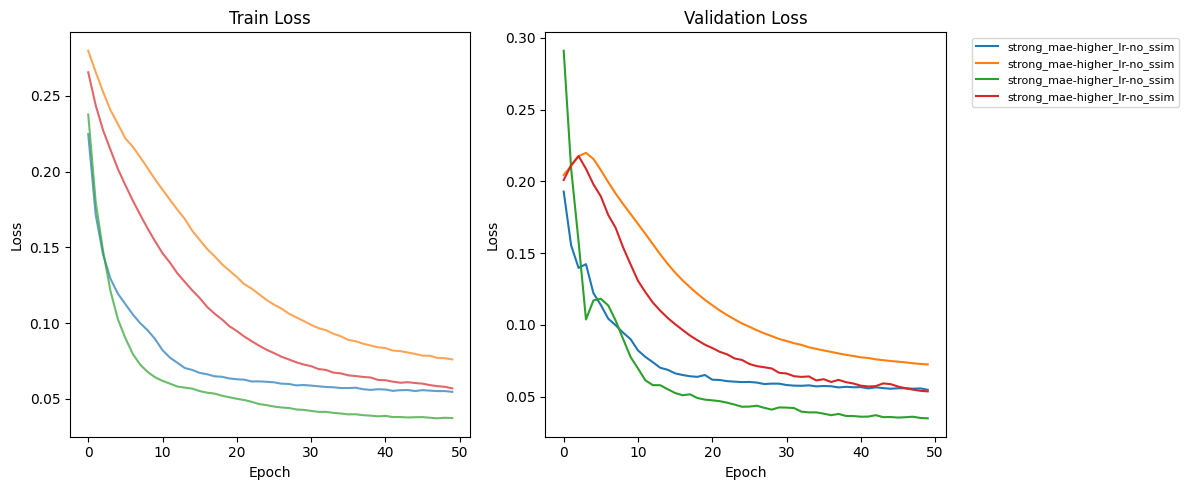

In [17]:
plt.figure(figsize=(12, 5))

# ---- TRAIN ----
plt.subplot(1, 2, 1)
for r in results:
    train_losses = r['losses']['train']
    plt.plot(train_losses, alpha=0.7)

plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ---- VAL ----
plt.subplot(1, 2, 2)
for r in results:
    val_losses = r['losses']['val']
    plt.plot(val_losses, label=r['name'])

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Legend only for val
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# 10. Best Model Selection + Evaluation

In [14]:
# Define weights for each metric
metric_weights = {
    'auc': 0.30,   # ROC-AUC
    'ap': 0.30,    # PR-AUC
    'recall': 0.15,    # catching anomalies is mor impt
    'f1': 0.10,        
    'precision': 0.10, 
    'accuracy': 0.05   # minor weight due to class imbalance
}

# Compute a weighted score for each result
for r in results:
    metrics = r['metrics']
    weighted_score = sum(metrics[k] * w for k, w in metric_weights.items())
    r['weighted_score'] = weighted_score
    print(f"{r['name']:<40} Weighted Score: {weighted_score:.4f}")

# Select best model based on weighted score
best = max(results, key=lambda x: x['weighted_score'])
print(f"\nBest config: {best['name']} (Weighted Score={best['weighted_score']:.4f})")

best_model = best['model']

strong_mae-higher_lr-no_ssim             Weighted Score: 0.7430
strong_mae-higher_lr-no_ssim             Weighted Score: 0.6783
strong_mae-higher_lr-no_ssim             Weighted Score: 0.5996
strong_mae-higher_lr-no_ssim             Weighted Score: 0.5537

Best config: strong_mae-higher_lr-no_ssim (Weighted Score=0.7430)


In [18]:
# Compute anomaly scores for test and val sets using the winning run's MAE/SSIM weight.
best_mae_weight = best.get('mae_weight_used', 0.4)
mae_scores, combined_scores, all_labels, val_combined = compute_scores(
    best_model,
    test_loader,
    val_loader,
    MAE_WEIGHT=best_mae_weight,
)

n_normal = int((all_labels == 0).sum())
n_anom   = int((all_labels == 1).sum())
print(f'\nTest set: {n_normal} normal, {n_anom} anomalous')
print(f'Best model MAE weight used for scoring: {best_mae_weight:.2f}')

best_model_name = best['name']
for tag, mae_s, comb_s in [(best_model_name, mae_scores, combined_scores)]:
    print(f'\nModel: [{tag}]')
    print(f'  MAE      — normal: {mae_s[all_labels==0].mean():.4f}, anom: {mae_s[all_labels==1].mean():.4f}')
    print(f'  Combined — normal: {comb_s[all_labels==0].mean():.4f}, anom: {comb_s[all_labels==1].mean():.4f}')

# Compute standard metrics using threshold from val set
threshold = val_combined.mean()
y_pred = (combined_scores > threshold).astype(int)

prec = precision_score(all_labels, y_pred)
rec  = recall_score(all_labels, y_pred)
f1   = f1_score(all_labels, y_pred)
acc  = accuracy_score(all_labels, y_pred)
bacc = balanced_accuracy_score(all_labels, y_pred)
roc  = roc_auc_score(all_labels, combined_scores)
ap   = average_precision_score(all_labels, combined_scores)

# Confusion matrix for FPR / FNR
tn, fp, fn, tp = confusion_matrix(all_labels, y_pred, labels=[0,1]).ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

results_dict = {
    'auc': roc,
    'ap': ap,
    'f1': f1,
    'recall': rec,
    'precision': prec,
    'accuracy': acc,
    'bacc': bacc,
    'reference_threshold': threshold,
    'fpr': fpr,
    'fnr': fnr
}
metrics = [
    ('ROC-AUC', 'auc'),
    ('PR-AUC', 'ap'),
    ('F1', 'f1'),
    ('Recall', 'recall'),
    ('Precision', 'precision'),
    ('Accuracy', 'accuracy'),
    ('Balanced Acc','bacc'),
    ('Threshold', 'reference_threshold'),
    ('FPR', 'fpr'),
    ('FNR', 'fnr'),
]
print(f"\nMetrics (reference_threshold={threshold:.4f}):")
for name, key in metrics:
    print(f"  {name:<12}: {results_dict[key]:.4f}")

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(



Test set: 58 normal, 92 anomalous
Best model MAE weight used for scoring: 1.00

Model: [strong_mae-higher_lr-no_ssim]
  MAE      — normal: 0.0527, anom: 0.0565
  Combined — normal: 0.0527, anom: 0.0565

Metrics (reference_threshold=0.0548):
  ROC-AUC     : 0.7344
  PR-AUC      : 0.8157
  F1          : 0.7030
  Recall      : 0.6304
  Precision   : 0.7945
  Accuracy    : 0.6733
  Balanced Acc: 0.6859
  Threshold   : 0.0548
  FPR         : 0.2586
  FNR         : 0.3696


In [ ]:
# # Sweep quantiles and select threshold
# QUANTILES = np.linspace(0.2, 0.99, 50)
# SELECTION_POLICY = 'fpr-constrained'
# MAX_FPR = 0.20

# auc = roc_auc_score(all_labels, combined_scores)
# ap  = average_precision_score(all_labels, combined_scores)

# sweep_rows = []
# for q in QUANTILES:
#     threshold = float(np.quantile(val_combined, q))
#     preds = (combined_scores >= threshold).astype(int)
#     prec = precision_score(all_labels, preds, zero_division=0)
#     rec  = recall_score(all_labels, preds, zero_division=0)
#     f1   = f1_score(all_labels, preds, zero_division=0)
#     acc  = accuracy_score(all_labels, preds)
#     bacc = balanced_accuracy_score(all_labels, preds)
#     tn, fp, fn, tp = confusion_matrix(all_labels, preds, labels=[0,1]).ravel()
#     fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
#     fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

#     sweep_rows.append({
#         'q': q, 'threshold': threshold,
#         'f1': f1, 'rec': rec, 'prec': prec,
#         'acc': acc, 'bacc': bacc,
#         'fpr': fpr_at_thr, 'fnr': fnr,
#         'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
#     })

# # Select best threshold
# if SELECTION_POLICY == 'fpr-constrained':
#     feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
#     if feasible:
#         selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
#     else:
#         selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
# else:
#     selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

# threshold = selected['threshold']

# print(f'Selected threshold: {threshold:.6f} (quantile={selected["q"]:.2f})')
# print(f'ROC-AUC: {auc:.4f}, PR-AUC: {ap:.4f}')
# print(f'F1={selected["f1"]:.4f}, Recall={selected["rec"]:.4f}, Precision={selected["prec"]:.4f}')
# print(f'Accuracy={selected["acc"]:.4f}, Balanced Acc={selected["bacc"]:.4f}')
# print(f'FPR={selected["fpr"]:.4f}, FNR={selected["fnr"]:.4f}')
# print(f'Confusion: TN={selected["tn"]}, FP={selected["fp"]}, FN={selected["fn"]}, TP={selected["tp"]}')

Selected threshold: 0.050675 (quantile=0.70)
ROC-AUC: 0.7564, PR-AUC: 0.8371
F1=0.6839, Recall=0.5761, Precision=0.8413
Accuracy=0.6733, Balanced Acc=0.7018
FPR=0.1724, FNR=0.4239
Confusion: TN=48, FP=10, FN=39, TP=53


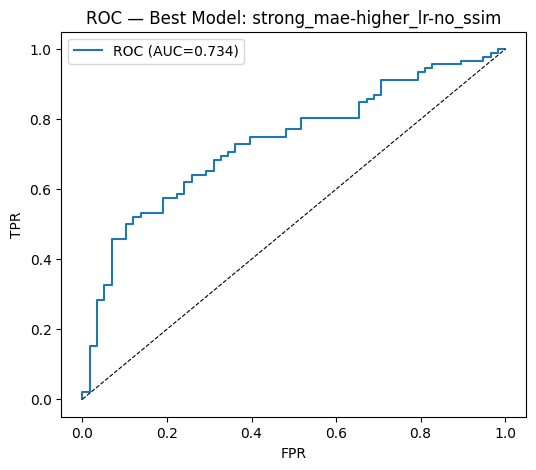

In [21]:
# Plot ROC curve
fpr_c, tpr_c, roc_thr = roc_curve(all_labels, combined_scores)
plot_idx = np.argmin(np.abs(roc_thr - threshold))

plt.figure(figsize=(6,5))
plt.plot(fpr_c, tpr_c, label=f'ROC (AUC={roc:.3f})')
# plt.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
#             label=f'Selected thr ({threshold:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC — Best Model: {best_model_name}')
plt.legend()
plt.show()


[strong_mae-higher_lr-no_ssim]  Pixel AUROC: 0.6161  Optimal threshold: 0.112807  Mean IoU: 0.0720  Std IoU: 0.0486


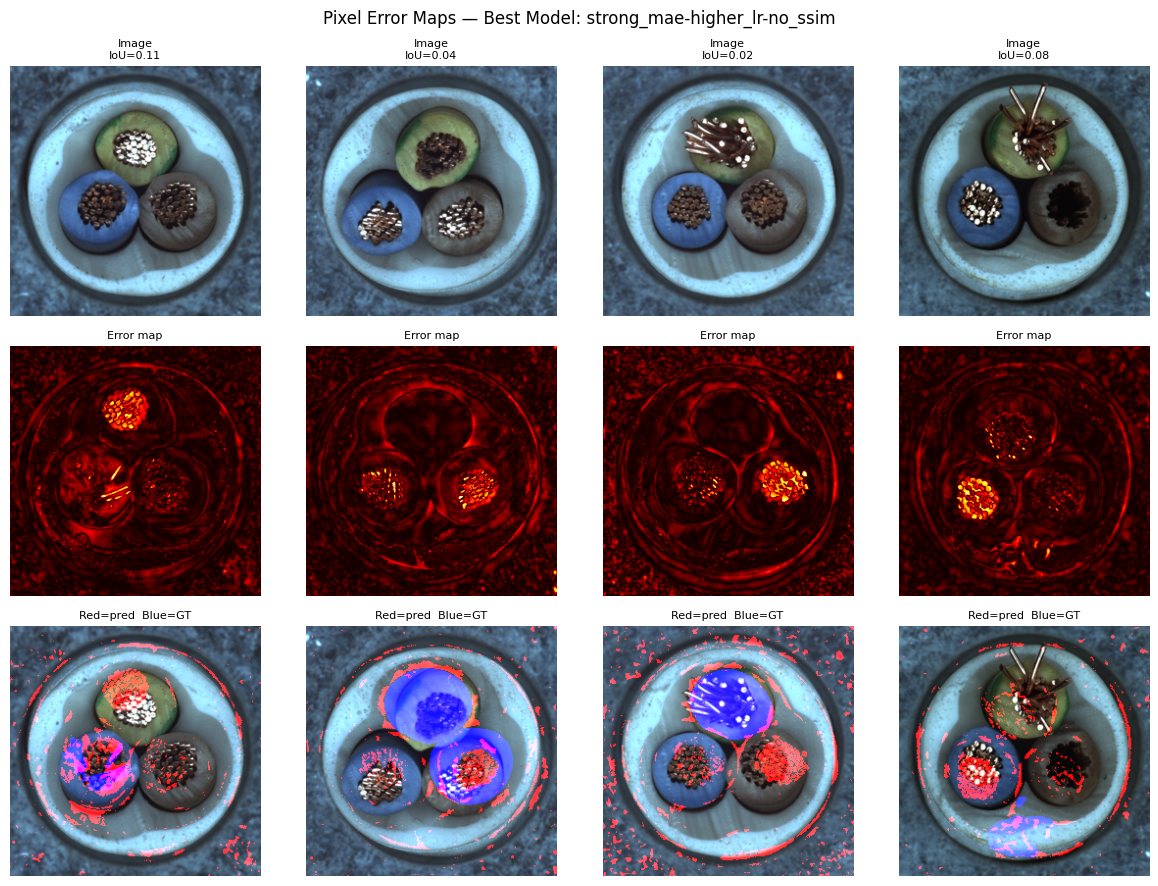

In [22]:
# Compute pixel-level maps
em_best, gt_best, iou_best, thr_best, px_auc = pixel_eval(best_model, best_model_name)

# Visualize a few images
n_vis = min(4, len(em_best))
vis_idx = np.linspace(0, len(em_best)-1, n_vis, dtype=int)

fig, axes = plt.subplots(3, n_vis, figsize=(3*n_vis, 9))
for col, vi in enumerate(vis_idx):
    orig = np.array(PILImage.open(test_loader.dataset.samples[vi][0]).convert('RGB').resize((256,256)))

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f'Image\nIoU={iou_best[vi]:.2f}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(em_best[vi], cmap='hot')
    axes[1, col].set_title('Error map', fontsize=8)
    axes[1, col].axis('off')

    overlay = orig.copy()
    overlay[(em_best[vi] >= thr_best), 0] = 255  # Red = predicted anomaly
    overlay[gt_best[vi].astype(bool), 2] = 255   # Blue = ground truth
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Red=pred  Blue=GT', fontsize=8)
    axes[2, col].axis('off')

plt.suptitle(f'Pixel Error Maps — Best Model: {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# Summary table
print(f"{'Metric':<22} {'Value':>12}")
print('-'*35)
summary_metrics = [
    ('ROC-AUC', roc),
    ('PR-AUC', ap),
    ('F1', selected['f1']),
    ('Recall', selected['rec']),
    ('Precision', selected['prec']),
    ('Accuracy', selected['acc']),
    ('Balanced Acc', selected['bacc']),
    ('Threshold', selected['threshold']),
    ('FPR', selected['fpr']),
    ('FNR', selected['fnr']),
]
for label, value in summary_metrics:
    print(f'{label:<22} {value:>12.4f}')
print('-'*35)

Metric                        Value
-----------------------------------


NameError: name 'selected' is not defined

In [ ]:
# Reference threshold metrics ---
ref_threshold = val_combined.mean()
y_pred_ref = (combined_scores > ref_threshold).astype(int)

prec_ref = precision_score(all_labels, y_pred_ref)
rec_ref  = recall_score(all_labels, y_pred_ref)
f1_ref   = f1_score(all_labels, y_pred_ref)
acc_ref  = accuracy_score(all_labels, y_pred_ref)
bacc_ref = balanced_accuracy_score(all_labels, y_pred_ref)
tn, fp, fn, tp = confusion_matrix(all_labels, y_pred_ref, labels=[0,1]).ravel()
fpr_ref = fp / (fp + tn)
fnr_ref = fn / (fn + tp)

# Optimized threshold metrics
opt_threshold = selected['threshold']
prec_opt = selected['prec']
rec_opt  = selected['rec']
f1_opt   = selected['f1']
acc_opt  = selected['acc']
bacc_opt = selected['bacc']
fpr_opt  = selected['fpr']
fnr_opt  = selected['fnr']

print(f"{'Metric':<22} {'Ref Thr.':>12} {'Optimized Thr.':>16}")
print('-'*52)

summary_metrics = [
    ('ROC-AUC', roc, roc),
    ('PR-AUC', ap, ap),
    ('F1', f1_ref, f1_opt),
    ('Recall', rec_ref, rec_opt),
    ('Precision', prec_ref, prec_opt),
    ('Accuracy', acc_ref, acc_opt),
    ('Balanced Acc', bacc_ref, bacc_opt),
    ('Threshold', ref_threshold, opt_threshold),
    ('FPR', fpr_ref, fpr_opt),
    ('FNR', fnr_ref, fnr_opt),
]

for label, ref_val, opt_val in summary_metrics:
    print(f"{label:<22} {ref_val:>12.4f} {opt_val:>16.4f}")

print('-'*52)

Metric                     Ref Thr.   Optimized Thr.
----------------------------------------------------
ROC-AUC                      0.7307           0.7307
PR-AUC                       0.8145           0.8145
F1                           0.5735           0.6122
Recall                       0.4239           0.4891
Precision                    0.8864           0.8182
Accuracy                     0.6133           0.6200
Balanced Acc                 0.6689           0.6584
Threshold                    0.2683           0.2644
FPR                          0.0862           0.1724
FNR                          0.5761           0.5109
----------------------------------------------------
